In [5]:
from dyn_model_class import ModelClass
from dyn_model_estim import *

import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from copy import deepcopy
from helper_functions import *
import matplotlib as mpl
from matplotlib.lines import Line2D
import os


%reload_ext autoreload
%autoreload 2

### Load data

In [6]:
### load data and make first 7 weeks of data for imputation
HR_pre_nonpar_u30 = pd.read_excel("data/HR_pre_nonpar_u30.xlsx")
HR_post_nonpar_u30 = pd.read_excel("data/HR_post_nonpar_u30.xlsx")

HR_pre_nonpar_o30 = pd.read_excel("data/HR_pre_nonpar_o30.xlsx")
HR_post_nonpar_o30 = pd.read_excel("data/HR_post_nonpar_o30.xlsx")

HR_pre_par = pd.read_excel("data/HR_pre_par.xlsx")
HR_post_par = pd.read_excel("data/HR_post_par.xlsx")

HR_post_agg = pd.read_excel("data/HR_post_agg.xlsx")
HR_pre_agg = pd.read_excel("data/HR_pre_agg.xlsx")

# take the first 7 weeks of data for imputation
HR_pre_nonpar_u30_impute = HR_pre_nonpar_u30.iloc[:7, :]
HR_pre_nonpar_o30_impute = HR_pre_nonpar_o30.iloc[:7, :]
HR_pre_par_impute = HR_pre_par.iloc[:7, :]
HR_pre_agg_impute = HR_pre_agg.iloc[:7, :]

HR_post_nonpar_u30_impute = HR_post_nonpar_u30.iloc[:7, :]
HR_post_nonpar_o30_impute = HR_post_nonpar_o30.iloc[:7, :]
HR_post_par_impute = HR_post_par.iloc[:7, :]
HR_post_agg_impute = HR_post_agg.iloc[:7, :]


# define population shares
shares_pre = [0.682, 0.119, 0.198]
shares_post = [0.716, 0.119, 0.165]

### Estimate model with shifted-log utility
#### Each group (non-parents under 30, non-parents over 30 and parents) estimated seperatly acroos pre- and post with multistart

In [ ]:
demo_groups = [("pre1", "post1"), ("pre2", "post2"), ("pre3", "post3")]

group_names = {
    "pre1": "Non-parents u30",
    "pre2": "Non-parents o30",
    "pre3": "Parents",
}

kappa3_fixed_map = {
    "pre1": False,
    "pre2": False,
    "pre3": False,
}

# Starting-value grids
gamma0_list = [0.5, 1.0, 1.5]
delta0_list = [0.60, 0.73, 0.85]

kappa1_list = [1.0, 5.0, 20.0]
kappa2_list = [50.0, 100.0, 200.0]
kappa3_list = [600.0, 1_339.0, 10_000.0, 45_000.0]

beta0_list = [-100.0, -600.0, -1_000.0]

type_shares0 = np.array([0.35, 0.40, 0.25])

individual_models  = {}
multistart_results = {}
theta              = {}  

# Separate multistart estimation for each group
for subgroups in demo_groups:

    pre, post = subgroups
    name      = group_names[pre]
    k3_fixed  = kappa3_fixed_map[pre]

    best_fun     = np.inf
    best_model   = None
    best_x       = None
    best_success = None
    best_msg     = None
    best_start   = None

    all_results = []
    n = 0

    print(f"\n{'=' * 75}")
    print(f"Estimating {name} with multistart")
    print(f"kappa3_fixed = {k3_fixed}")
    print(f"{'=' * 75}")

    if k3_fixed is not False:
        starting_grid = itertools.product(
            gamma0_list, delta0_list,
            kappa1_list, kappa2_list, [float(k3_fixed)],
            beta0_list,
        )
    else:
        starting_grid = itertools.product(
            gamma0_list, delta0_list,
            kappa1_list, kappa2_list, kappa3_list,
            beta0_list,
        )

    for gamma0, delta0, k1_0, k2_0, k3_0, beta0 in starting_grid:

        if not (k1_0 < k2_0 < k3_0):
            continue

        n += 1

        model = ModelClass(
            groups=(pre, post),
            util_type="log_shift",
            delta_fixed=False,
            kappa3_fixed=k3_fixed,
        )

        model.update_initial_values(
            gamma0=gamma0,
            delta0=delta0,
            kappa0=np.array([k1_0, k2_0, k3_0]),
            type_shares0=type_shares0,
        )

        model.update_group_initial_values(pre,  beta0=beta0)
        model.update_group_initial_values(post, beta0=beta0)

        try:
            x, fun, success, msg = gmm_estimate_prepost(
                model.par,
                model.sol,
                model.data,
                demo_groups=[subgroups],
            )
        except Exception as err:
            print(f"  [{n:>4}] FAILED: {err}")
            continue

        result = {
            "start_number": n,
            "gamma0":  gamma0,
            "delta0":  delta0,
            "kappa0":  np.array([k1_0, k2_0, k3_0]),
            "beta0":   beta0,
            "fun":     fun,
            "success": success,
            "msg":     msg,
            "x":       x,
            "model":   model,
        }

        all_results.append(result)

        if np.isfinite(fun) and fun < best_fun:
            best_fun     = fun
            best_model   = model
            best_x       = x          
            best_success = success
            best_msg     = msg
            best_start   = result

            print(
                f"  [{n:>4}] NEW BEST  "
                f"obj={fun:.4f}  "
                f"gamma={model.par.gamma:.4f}  "
                f"delta={model.par.delta:.4f}  "
                f"beta_pre={getattr(model.par, pre).beta:.2f}  "
                f"beta_post={getattr(model.par, post).beta:.2f}"
            )

    if best_model is None:
        print(f"\nNo finite solution found for {name}.")
        individual_models[pre]  = None
        multistart_results[pre] = all_results
        continue

    individual_models[pre]  = best_model
    multistart_results[pre] = all_results
    theta[pre]              = best_x   

    print(f"\nBest result for {name}")
    print(f"  Total starts = {n}")
    print(f"  Best obj     = {best_fun:.4f}")
    print(f"  Success      = {best_success}")
    print(f"  Message      = {best_msg}")
    print(f"  Start values = gamma0={best_start['gamma0']}, "
          f"delta0={best_start['delta0']}, "
          f"kappa0={best_start['kappa0']}, "
          f"beta0={best_start['beta0']}")
    print(f"  gamma        = {best_model.par.gamma:.4f}")
    print(f"  delta        = {best_model.par.delta:.4f}")
    print(f"  kappa        = {getattr(best_model.par, pre).kappa}")
    print(f"  beta, pre    = {getattr(best_model.par, pre).beta:.2f}")
    print(f"  beta, post   = {getattr(best_model.par, post).beta:.2f}")


    # Bound check for the selected solution
    bounds = build_bounds_prepost(best_model.par, [subgroups])

    print("  Bound check")
    for i, (lb, ub) in enumerate(bounds):
        val   = best_x[i]
        at_lb = np.isclose(val, lb, atol=1e-4)
        at_ub = np.isclose(val, ub, atol=1e-4)
        flag  = (
            " <- AT LOWER BOUND" if at_lb else
            " <- AT UPPER BOUND" if at_ub else ""
        )
        print(
            f"    x[{i:2d}] = {val:10.4f}  "
            f"bounds=({lb:.4f}, {ub:.4f}){flag}"
        )

### Plot model fit

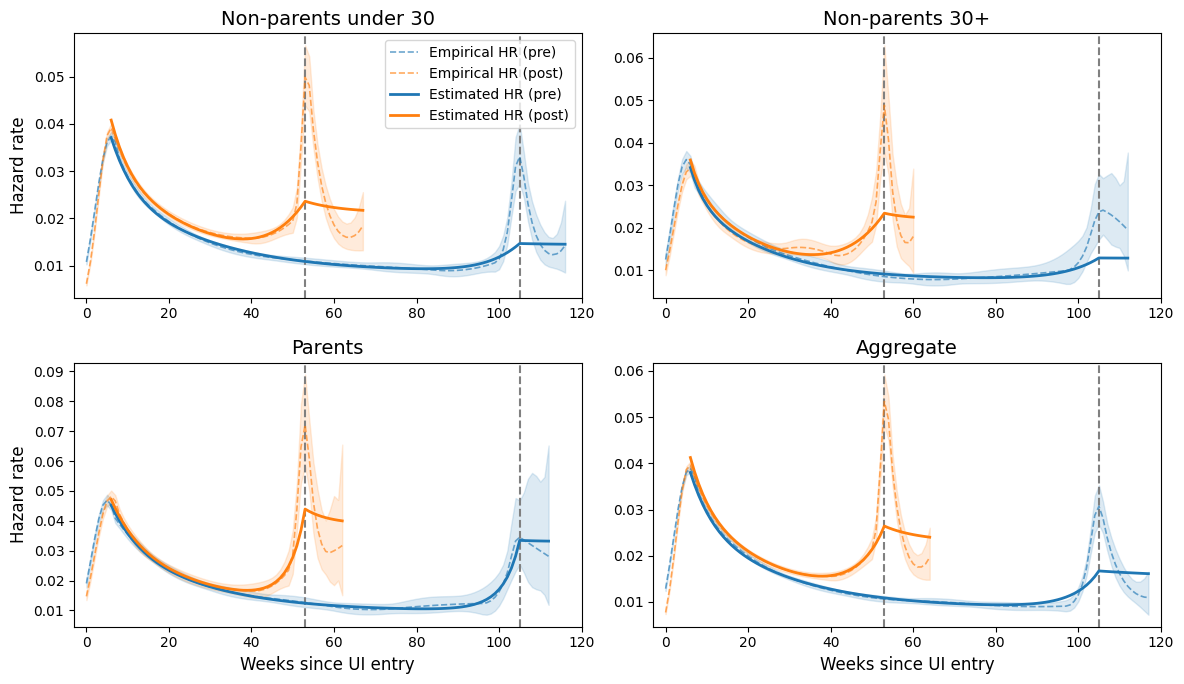

In [10]:
mpl.rcParams.update({
    "font.size":        12,
    "axes.titlesize":   13,
    "axes.labelsize":   12,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "legend.fontsize":  10,
})

width    = 2
d_width  = 1.2
alpha    = 0.65
alpha_fill = 0.15
x_pad    = 3

# simulate using individual models
for subgroups in demo_groups:
    pre, post = subgroups
    model = individual_models[pre]
    sim_hr_prepost(model.par, model.sol, [subgroups])

# collect data and solutions from individual models
m1 = individual_models["pre1"]
m2 = individual_models["pre2"]
m3 = individual_models["pre3"]

ms = m1.par.moments_start

x_pre_u   = np.arange(len(m1.data.pre1.moments))
x_post_u  = np.arange(len(m1.data.post1.moments))
x_pre_o   = np.arange(len(m2.data.pre2.moments))
x_post_o  = np.arange(len(m2.data.post2.moments))
x_pre_par = np.arange(len(m3.data.pre3.moments))
x_post_par= np.arange(len(m3.data.post3.moments))

x_pre_u_trim   = np.arange(ms, len(m1.data.pre1.moments))
x_post_u_trim  = np.arange(ms, len(m1.data.post1.moments))
x_pre_o_trim   = np.arange(ms, len(m2.data.pre2.moments))
x_post_o_trim  = np.arange(ms, len(m2.data.post2.moments))
x_pre_par_trim = np.arange(ms, len(m3.data.pre3.moments))
x_post_par_trim= np.arange(ms, len(m3.data.post3.moments))

T_agg_pre  = len(HR_pre_agg)
T_agg_post = len(HR_post_agg)

x_trim_pre = max(len(m1.data.pre1.moments),
                 len(m2.data.pre2.moments),
                 len(m3.data.pre3.moments))

# simulate all pre-reform groups to same length
pre1_moments = simulate_to_length(m1, "pre1", T_agg_pre)
pre2_moments = simulate_to_length(m2, "pre2", T_agg_pre)
pre3_moments = simulate_to_length(m3, "pre3", T_agg_pre)

agg_pre = aggregate_hazard(
    moments_list=[pre1_moments, pre2_moments, pre3_moments],
    shares=shares_post)

T_agg_post = len(HR_post_agg)

post1_moments = simulate_to_length(m1, "post1", T_agg_post)
post2_moments = simulate_to_length(m2, "post2", T_agg_post)
post3_moments = simulate_to_length(m3, "post3", T_agg_post)

agg_post = aggregate_hazard(
    moments_list=[post1_moments, post2_moments, post3_moments],
    shares=shares_post)

t_pre_agg  = np.arange(len(agg_pre))
t_post_agg = np.arange(len(agg_post))

x_pre_agg  = np.arange(len(HR_pre_agg))
x_post_agg = np.arange(len(HR_post_agg))

# ── Plot 2x2 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey = False)
ax1, ax2  = axes[0, 0], axes[0, 1]
ax3, ax4  = axes[1, 0], axes[1, 1]

# ── Non-parents u30 ───────────────────────────────────────────────────────────
ax1.axvline(x=53,  color="gray", linestyle="--")
ax1.axvline(x=105, color="gray", linestyle="--")
ax1.plot(m1.data.pre1.moments,  label="Empirical HR (pre)",  color="C0",        linestyle="--", linewidth=d_width, alpha=alpha)
ax1.fill_between(x_pre_u,  m1.data.pre1.lower,  m1.data.pre1.upper,  color="C0",        alpha=alpha_fill)
ax1.plot(m1.data.post1.moments, label="Empirical HR (post)", color="tab:orange", linestyle="--", linewidth=d_width, alpha=alpha)
ax1.fill_between(x_post_u, m1.data.post1.lower, m1.data.post1.upper, color="tab:orange", alpha=alpha_fill)
ax1.plot(x_pre_u_trim,  m1.sol.pre1.moments[x_pre_u_trim],   label="Estimated HR (pre)",  color="C0",        linestyle="-", linewidth=width)
ax1.plot(x_post_u_trim, m1.sol.post1.moments[x_post_u_trim], label="Estimated HR (post)", color="tab:orange", linestyle="-", linewidth=width)
ax1.set_title("Non-parents under 30")
ax1.legend(fontsize=10)

# ── Non-parents o30 ───────────────────────────────────────────────────────────
ax2.axvline(x=53,  color="gray", linestyle="--")
ax2.axvline(x=105, color="gray", linestyle="--")
ax2.plot(m2.data.pre2.moments,  label="Empirical HR (pre)",  color="C0",        linestyle="--", linewidth=d_width, alpha=alpha)
ax2.fill_between(x_pre_o,  m2.data.pre2.lower,  m2.data.pre2.upper,  color="C0",        alpha=alpha_fill)
ax2.plot(m2.data.post2.moments, label="Empirical HR (post)", color="tab:orange", linestyle="--", linewidth=d_width, alpha=alpha)
ax2.fill_between(x_post_o, m2.data.post2.lower, m2.data.post2.upper, color="tab:orange", alpha=alpha_fill)
ax2.plot(x_pre_o_trim,  m2.sol.pre2.moments[x_pre_o_trim],   label="Estimated HR (pre)",  color="C0",        linestyle="-", linewidth=width)
ax2.plot(x_post_o_trim, m2.sol.post2.moments[x_post_o_trim], label="Estimated HR (post)", color="tab:orange", linestyle="-", linewidth=width)
ax2.set_title("Non-parents 30+")
#ax2.legend(fontsize=10)

# ── Parents ───────────────────────────────────────────────────────────────────
ax3.axvline(x=53,  color="gray", linestyle="--")
ax3.axvline(x=105, color="gray", linestyle="--")
ax3.plot(m3.data.pre3.moments,  label="Empirical HR (pre)",  color="C0",        linestyle="--", linewidth=d_width, alpha=alpha)
ax3.fill_between(x_pre_par,  m3.data.pre3.lower,  m3.data.pre3.upper,  color="C0",        alpha=alpha_fill)
ax3.plot(m3.data.post3.moments, label="Empirical HR (post)", color="tab:orange", linestyle="--", linewidth=d_width, alpha=alpha)
ax3.fill_between(x_post_par, m3.data.post3.lower, m3.data.post3.upper, color="tab:orange", alpha=alpha_fill)
ax3.plot(x_pre_par_trim,  m3.sol.pre3.moments[x_pre_par_trim],   label="Estimated HR (pre)",  color="C0",        linestyle="-", linewidth=width)
ax3.plot(x_post_par_trim, m3.sol.post3.moments[x_post_par_trim], label="Estimated HR (post)", color="tab:orange", linestyle="-", linewidth=width)
ax3.set_title("Parents")
#ax3.legend(fontsize=10)

# ── Aggregate ─────────────────────────────────────────────────────────────────
ax4.axvline(x=53,  color="gray", linestyle="--")
ax4.axvline(x=105, color="gray", linestyle="--")
ax4.plot(HR_pre_agg["HR_logit"],  label="Empirical HR (pre)",  color="C0",        linestyle="--", linewidth=d_width, alpha=alpha)
ax4.fill_between(x_pre_agg,  HR_pre_agg["Lower_CI"],  HR_pre_agg["Upper_CI"],  color="C0",        alpha=alpha_fill)
ax4.plot(HR_post_agg["HR_logit"], label="Empirical HR (post)", color="tab:orange", linestyle="--", linewidth=d_width, alpha=alpha)
ax4.fill_between(x_post_agg, HR_post_agg["Lower_CI"], HR_post_agg["Upper_CI"], color="tab:orange", alpha=alpha_fill)
ax4.plot(t_pre_agg[ms:],  agg_pre[ms:],  label="Estimated HR (pre)",  color="C0",        linestyle="-", linewidth=width)
ax4.plot(t_post_agg[ms:], agg_post[ms:], label="Estimated HR (post)", color="tab:orange", linestyle="-", linewidth=width)
ax4.set_title("Aggregate")
#ax4.legend(fontsize=10)

# ── Shared axis settings ──────────────────────────────────────────────────────
axes[0, 0].set_xlabel("")
axes[0, 1].set_xlabel("")
axes[1, 0].set_xlabel("Weeks since UI entry")
axes[1, 1].set_xlabel("Weeks since UI entry")

axes[0, 0].set_ylabel("Hazard rate", fontsize=12)
axes[1, 0].set_ylabel("Hazard rate", fontsize=12)
axes[0, 1].set_ylabel("")
axes[1, 1].set_ylabel("")

for ax in axes.flat:
    ax.set_xlim(-x_pad, x_trim_pre + x_pad)
    ax.title.set_fontsize(14)
    ax.title.set_fontweight("normal")

plt.tight_layout()
#plt.savefig("model_fit_log_shift.pdf", bbox_inches="tight")
plt.show()

### Compute SE and collect estimated parameters

In [11]:
se_results = {}

for subgroups in demo_groups:
    pre, post = subgroups
    name      = group_names[pre]
    model     = individual_models[pre]
    x         = theta[pre]

    print(f"\n── Standard errors: {name} ──────────────────")

    se, var_theta = par_SE(
        par         = model.par,
        sol         = model.sol,
        data        = model.data,
        demo_groups = [subgroups],
        theta       = x)

    print(f"  len(theta)={len(x)}  len(se)={len(se)}")

    gpar      = getattr(model.par, pre)
    K         = model.par.n_types
    kappas    = gpar.kappa
    shares    = gpar.type_shares
    k3_fixed  = model.par.kappa3_fixed
    nk        = K - 1 if k3_fixed is not False else K  # estimated kappa params
    idx       = 0
    se_orig   = {}

    # ── kappa parameters ──────────────────────────────────────────────────────
    se_orig["kappa1"] = kappas[0] * se[idx]; idx += 1
    se_orig["kappa2"] = (kappas[1] - kappas[0]) * se[idx]; idx += 1
    if k3_fixed is not False:
        se_orig["kappa3"] = float("nan")  # fixed — no SE
    else:
        se_orig["kappa3"] = (kappas[2] - kappas[1]) * se[idx]; idx += 1

    # ── gamma ─────────────────────────────────────────────────────────────────
    se_orig["gamma"] = model.par.gamma * se[idx]; idx += 1

    # ── delta ─────────────────────────────────────────────────────────────────
    if model.par.delta_fixed == False:
        se_orig["delta"] = model.par.delta * (1 - model.par.delta) * se[idx]; idx += 1
    else:
        se_orig["delta"] = float("nan")  # fixed — no SE

    # ── shares via softmax Jacobian ───────────────────────────────────────────
    z      = np.append(x[idx:idx+K-1], 0.0)
    exp_z  = np.exp(z - np.max(z))
    p      = exp_z / exp_z.sum()
    J_soft = np.diag(p) - np.outer(p, p)
    J_free = J_soft[:, :K-1]
    var_shares_trans = var_theta[idx:idx+K-1, idx:idx+K-1]
    var_shares_orig  = J_free @ var_shares_trans @ J_free.T
    for k in range(K):
        se_orig[f"pi{k+1}"] = np.sqrt(var_shares_orig[k, k])
    idx += K - 1

    # ── beta ──────────────────────────────────────────────────────────────────
    if model.par.util_type in ("log_shift", "CRRA_shift", "sqrt_shift"):
        gap = gpar.b3 + gpar.beta  # gap = exp(x[idx])
        se_orig["beta"] = gap * se[idx]; idx += 1

    # store
    se_results[pre] = {"se_orig": se_orig, "se_trans": se,
                       "var_theta": var_theta}

    # ── print ─────────────────────────────────────────────────────────────────
    print(f"  {'Parameter':10s}  {'Estimate':>10s}  {'SE':>10s}  {'t-stat':>8s}")
    print(f"  {'-'*45}")
    params_est = (
        [(f"kappa{k+1}", kappas[k]) for k in range(K)] +
        [("gamma", model.par.gamma), ("delta", model.par.delta)] +
        [(f"pi{k+1}", shares[k]) for k in range(K)] +
        ([("beta", gpar.beta)] if model.par.util_type in
         ("log_shift", "CRRA_shift", "sqrt_shift") else [])
    )
    for pname, est in params_est:
        se_val = se_orig.get(pname, float("nan"))
        tstat  = est / se_val if (se_val > 0 and np.isfinite(se_val)) else np.nan
        fix    = " (fixed)" if np.isnan(se_val) else ""
        print(f"  {pname:10s}  {est:10.4f}  {se_val:10.4f}  {tstat:8.2f}{fix}")


── Standard errors: Non-parents u30 ──────────────────
  len(theta)=8  len(se)=8
  Parameter     Estimate          SE    t-stat
  ---------------------------------------------
  kappa1        147.3022     85.2164      1.73
  kappa2       3920.6829   2998.1177      1.31
  kappa3      358495.6382  475683.9384      0.75
  gamma           2.3223      5.0171      0.46
  delta           0.8511      0.0158     54.03
  pi1             0.1991      0.0320      6.21
  pi2             0.3229      0.0132     24.42
  pi3             0.4780      0.0209     22.89
  beta        -1084.2010     15.2310    -71.18

── Standard errors: Non-parents o30 ──────────────────
  len(theta)=8  len(se)=8
  Parameter     Estimate          SE    t-stat
  ---------------------------------------------
  kappa1         41.4667     45.3654      0.91
  kappa2        943.2289   1403.1812      0.67
  kappa3      62972.3602  183918.6793      0.34
  gamma           1.8322     10.1013      0.18
  delta           0.8754      0.

In [12]:
# ── collect parameters and SE for all groups into one table ───────────────────
rows = {}

for pre, model in individual_models.items():
    name  = group_names[pre]
    par   = model.par
    gpar  = getattr(par, pre)
    K     = par.n_types
    se    = se_results[pre]["se_orig"]
    col   = {}

    # ── kappa ─────────────────────────────────────────────────────────────────
    for k in range(K):
        fixed = (k == K-1) and (par.kappa3_fixed is not False)
        col[f"$\\kappa_{{{k+1}}}$"]      = f"{gpar.kappa[k]:.4f}"
        col[f"$\\kappa_{{{k+1}}}$ (SE)"] = "" if fixed else f"({se[f'kappa{k+1}']:.4f})"

    # ── type shares ───────────────────────────────────────────────────────────
    for k in range(K):
        col[f"$\\pi_{{{k+1}}}$"]      = f"{gpar.type_shares[k]:.4f}"
        col[f"$\\pi_{{{k+1}}}$ (SE)"] = f"({se[f'pi{k+1}']:.4f})"

    # ── beta (log_shift) ──────────────────────────────────────────────────────
    col["$\\beta$"]      = f"{gpar.beta:.4f}"
    col["$\\beta$ (SE)"] = f"({se.get('beta', float('nan')):.4f})"

    # ── gamma ─────────────────────────────────────────────────────────────────
    col["$\\gamma$"]      = f"{par.gamma:.4f}"
    col["$\\gamma$ (SE)"] = f"({se['gamma']:.4f})"

    # ── delta ─────────────────────────────────────────────────────────────────
    fixed_delta = par.delta_fixed is not False
    col["$\\delta$"]      = f"{par.delta:.4f}"
    col["$\\delta$ (SE)"] = "" if fixed_delta else f"({se['delta']:.4f})"

    rows[name] = col

# ── build dataframe ───────────────────────────────────────────────────────────
df = pd.DataFrame(rows)

param_order = []
for k in range(K):
    param_order += [f"$\\kappa_{{{k+1}}}$", f"$\\kappa_{{{k+1}}}$ (SE)"]
for k in range(K):
    param_order += [f"$\\pi_{{{k+1}}}$", f"$\\pi_{{{k+1}}}$ (SE)"]
param_order += [
    "$\\beta$", "$\\beta$ (SE)",
    "$\\gamma$", "$\\gamma$ (SE)",
    "$\\delta$", "$\\delta$ (SE)",
]

df = df.reindex([p for p in param_order if p in df.index])
col_order = [group_names[pre] for pre in ["pre1", "pre2", "pre3"]]
df = df[col_order]

display(df)

# ── export to latex ───────────────────────────────────────────────────────────
latex = df.to_latex(
    escape        = False,
    column_format = "l" + "r" * len(col_order),
    caption       = "Estimated structural parameters (shifted log utility)",
    label         = "tab:parameters",
    na_rep        = ""
)
print(latex)

,Non-parents u30,Non-parents o30,Parents
$\kappa_{1}$,147.3022,41.4667,10.4613
$\kappa_{1}$ (SE),(85.2164),(45.3654),(9.7782)
$\kappa_{2}$,3920.6829,943.2289,23.9414
$\kappa_{2}$ (SE),(2998.1177),(1403.1812),(24.4217)
$\kappa_{3}$,358495.6382,62972.3602,79.6050
$\kappa_{3}$ (SE),(475683.9384),(183918.6793),(146.1408)
$\pi_{1}$,0.1991,0.1727,0.2377
$\pi_{1}$ (SE),(0.0320),(0.0398),(0.0592)
$\pi_{2}$,0.3229,0.3118,0.3575
$\pi_{2}$ (SE),(0.0132),(0.0161),(0.0431)


\begin{table}
\caption{Estimated structural parameters (shifted log utility)}
\label{tab:parameters}
\begin{tabular}{lrrr}
\toprule
 & Non-parents u30 & Non-parents o30 & Parents \\
\midrule
$\kappa_{1}$ & 147.3022 & 41.4667 & 10.4613 \\
$\kappa_{1}$ (SE) & (85.2164) & (45.3654) & (9.7782) \\
$\kappa_{2}$ & 3920.6829 & 943.2289 & 23.9414 \\
$\kappa_{2}$ (SE) & (2998.1177) & (1403.1812) & (24.4217) \\
$\kappa_{3}$ & 358495.6382 & 62972.3602 & 79.6050 \\
$\kappa_{3}$ (SE) & (475683.9384) & (183918.6793) & (146.1408) \\
$\pi_{1}$ & 0.1991 & 0.1727 & 0.2377 \\
$\pi_{1}$ (SE) & (0.0320) & (0.0398) & (0.0592) \\
$\pi_{2}$ & 0.3229 & 0.3118 & 0.3575 \\
$\pi_{2}$ (SE) & (0.0132) & (0.0161) & (0.0431) \\
$\pi_{3}$ & 0.4780 & 0.5155 & 0.4049 \\
$\pi_{3}$ (SE) & (0.0209) & (0.0289) & (0.0338) \\
$\beta$ & -1084.2010 & -1886.2899 & -1913.2642 \\
$\beta$ (SE) & (15.2310) & (22.7689) & (118.7938) \\
$\gamma$ & 2.3223 & 1.8322 & 0.6124 \\
$\gamma$ (SE) & (5.0171) & (10.1013) & (1.6888) \\
$\delta$ & 

### Saved model-implied HR (for plotting in seperate notebook)

In [13]:
os.makedirs("output", exist_ok=True)

for subgroups in demo_groups:
    pre, post = subgroups
    model = individual_models[pre]
    ms    = model.par.moments_start

    sim_pre  = pd.DataFrame({"week": np.arange(ms, ms + len(model.sol.__dict__[pre].moments[ms:])),  "hr": model.sol.__dict__[pre].moments[ms:]})
    sim_post = pd.DataFrame({"week": np.arange(ms, ms + len(model.sol.__dict__[post].moments[ms:])), "hr": model.sol.__dict__[post].moments[ms:]})

    sim_pre.to_csv( f"output/{pre}_simulated_logshift.csv",  index=False)
    sim_post.to_csv(f"output/{post}_simulated_logshift.csv", index=False)
    print(f"Saved {pre}/{post}: sim_pre={len(sim_pre)}, sim_post={len(sim_post)} rows")

# ── aggregate ─────────────────────────────────────────────────────────────────
ms = m1.par.moments_start

sim_agg_pre_df  = pd.DataFrame({"week": np.arange(ms, ms + len(agg_pre[ms:])),  "hr": agg_pre[ms:]})
sim_agg_post_df = pd.DataFrame({"week": np.arange(ms, ms + len(agg_post[ms:])), "hr": agg_post[ms:]})

sim_agg_pre_df.to_csv( "output/agg_pre_simulated_logshift.csv",  index=False)
sim_agg_post_df.to_csv("output/agg_post_simulated_logshift.csv", index=False)
print("Saved aggregate pre/post simulated.")

Saved pre1/post1: sim_pre=111, sim_post=62 rows
Saved pre2/post2: sim_pre=107, sim_post=55 rows
Saved pre3/post3: sim_pre=107, sim_post=57 rows
Saved aggregate pre/post simulated.


### Plot hazard curves for each specific search-cost type

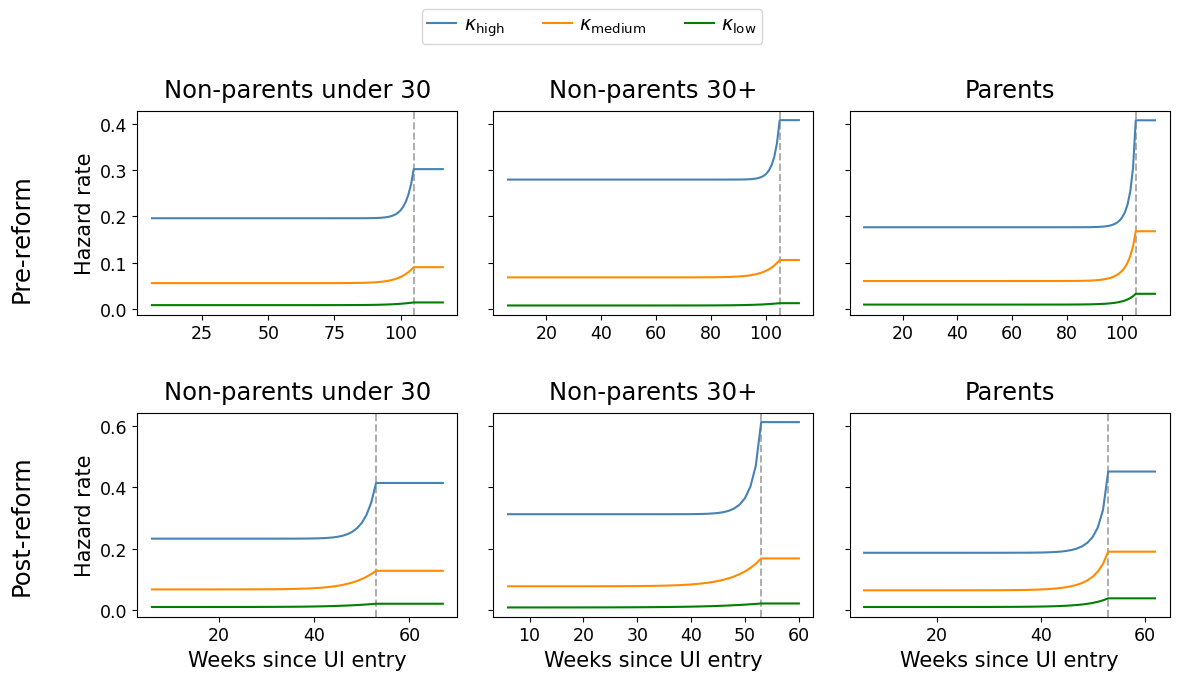

In [15]:

# ── Typography ────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.size": 15, "axes.titlesize": 17.5, "axes.labelsize": 15,
    "xtick.labelsize": 12.5, "ytick.labelsize": 12.5, "legend.fontsize": 13.75,
})
TITLE_SIZE, LABEL_SIZE, TICK_SIZE, ROW_LABEL_SIZE, LEGEND_SIZE = 17.5, 15, 12.5, 17.5, 13.75

# ── Simulate ──────────────────────────────────────────────────────────────────
for subgroups in demo_groups:
    pre, post = subgroups
    model = individual_models[pre]
    sim_hr_prepost(model.par, model.sol, [subgroups])

# ── Collect ───────────────────────────────────────────────────────────────────
m1, m2, m3 = individual_models["pre1"], individual_models["pre2"], individual_models["pre3"]

ms = m1.par.moments_start
x_pre_u_trim    = np.arange(ms, len(m1.data.pre1.moments))
x_post_u_trim   = np.arange(ms, len(m1.data.post1.moments))
x_pre_o_trim    = np.arange(ms, len(m2.data.pre2.moments))
x_post_o_trim   = np.arange(ms, len(m2.data.post2.moments))
x_pre_par_trim  = np.arange(ms, len(m3.data.pre3.moments))
x_post_par_trim = np.arange(ms, len(m3.data.post3.moments))

# ── Plot settings ─────────────────────────────────────────────────────────────
type_colors  = ["steelblue", "darkorange", "green"]
type_labels  = [r"$\kappa_{\mathrm{high}}$", r"$\kappa_{\mathrm{medium}}$", r"$\kappa_{\mathrm{low}}$"]
subplot_titles = ["Non-parents under 30", "Non-parents 30+", "Parents"]
hazard_linewidth, reference_color, reference_linewidth, reference_alpha = 1.5, "0.6", 1.4, 0.8

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey="row")

row_configs = [
    (axes[0], [(m1,"pre1",x_pre_u_trim), (m2,"pre2",x_pre_o_trim), (m3,"pre3",x_pre_par_trim)],     105),
    (axes[1], [(m1,"post1",x_post_u_trim), (m2,"post2",x_post_o_trim), (m3,"post3",x_post_par_trim)], 53),
]

for row_axes, row_data, vline_x in row_configs:
    for ax, (m, group, x_trim), title in zip(row_axes, row_data, subplot_titles + [None, None, None]):
        gpar, gsol = getattr(m.par, group), getattr(m.sol, group)
        for k in range(m.par.n_types):
            ax.plot(x_trim, gsol.s[k, x_trim], color=type_colors[k], linestyle="-", linewidth=hazard_linewidth, label=type_labels[k])
        ax.axvline(x=vline_x, color=reference_color, linestyle="--", linewidth=reference_linewidth, alpha=reference_alpha, zorder=0)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        ax.grid(False)
        if title:
            ax.set_title(title, fontsize=TITLE_SIZE, fontweight="normal", pad=10)

# ── Axis labels ───────────────────────────────────────────────────────────────
axes[0, 0].set_ylabel("Hazard rate", fontsize=LABEL_SIZE)
axes[1, 0].set_ylabel("Hazard rate", fontsize=LABEL_SIZE)
for ax in axes[1]:
    ax.set_xlabel("Weeks since UI entry", fontsize=LABEL_SIZE)

# ── Row labels ────────────────────────────────────────────────────────────────
fig.text(0.025, 0.68, "Pre-reform",  rotation=90, va="center", ha="center", fontsize=ROW_LABEL_SIZE)
fig.text(0.025, 0.27, "Post-reform", rotation=90, va="center", ha="center", fontsize=ROW_LABEL_SIZE)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [Line2D([0], [0], color=c, linewidth=hazard_linewidth, label=l) for c, l in zip(type_colors, type_labels)]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=True, fontsize=LEGEND_SIZE,
           bbox_to_anchor=(0.5, 1.02), labelspacing=0.15, handlelength=1.5, handletextpad=0.4, borderpad=0.3)

# ── Layout and export ─────────────────────────────────────────────────────────
plt.tight_layout(rect=[0.05, 0.03, 1, 0.94], w_pad=1.5, h_pad=1.8)
#plt.savefig("cost_types_logshift_all.pdf", bbox_inches="tight")
plt.show()

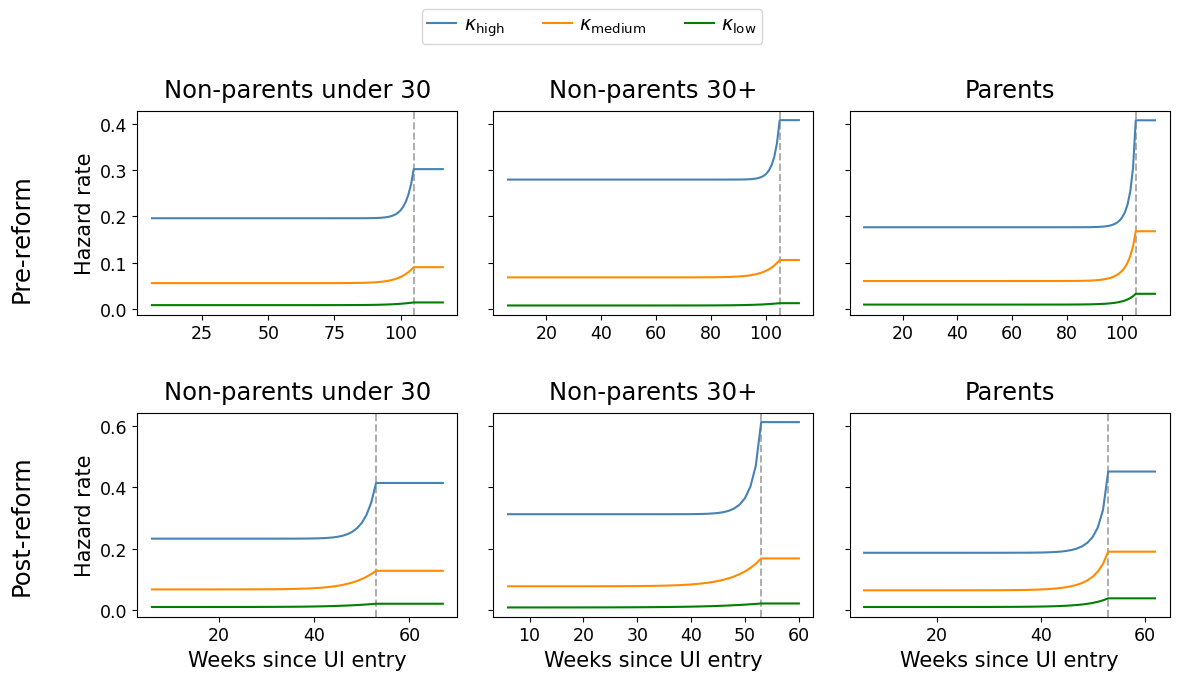

In [16]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Typography ────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.size": 15, "axes.titlesize": 17.5, "axes.labelsize": 15,
    "xtick.labelsize": 12.5, "ytick.labelsize": 12.5, "legend.fontsize": 13.75,
})
TITLE_SIZE, LABEL_SIZE, TICK_SIZE, ROW_LABEL_SIZE, LEGEND_SIZE = 17.5, 15, 12.5, 17.5, 13.75

# ── Simulate ──────────────────────────────────────────────────────────────────
for subgroups in demo_groups:
    pre, post = subgroups
    model = individual_models[pre]
    sim_hr_prepost(model.par, model.sol, [subgroups])

# ── Collect ───────────────────────────────────────────────────────────────────
m1, m2, m3 = individual_models["pre1"], individual_models["pre2"], individual_models["pre3"]

ms = m1.par.moments_start
x_pre_u_trim    = np.arange(ms, len(m1.data.pre1.moments))
x_post_u_trim   = np.arange(ms, len(m1.data.post1.moments))
x_pre_o_trim    = np.arange(ms, len(m2.data.pre2.moments))
x_post_o_trim   = np.arange(ms, len(m2.data.post2.moments))
x_pre_par_trim  = np.arange(ms, len(m3.data.pre3.moments))
x_post_par_trim = np.arange(ms, len(m3.data.post3.moments))

# ── Plot settings ─────────────────────────────────────────────────────────────
type_colors  = ["steelblue", "darkorange", "green"]
type_labels  = [r"$\kappa_{\mathrm{high}}$", r"$\kappa_{\mathrm{medium}}$", r"$\kappa_{\mathrm{low}}$"]
subplot_titles = ["Non-parents under 30", "Non-parents 30+", "Parents"]
hazard_linewidth, reference_color, reference_linewidth, reference_alpha = 1.5, "0.6", 1.4, 0.8

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey="row")

row_configs = [
    (axes[0], [(m1,"pre1",x_pre_u_trim), (m2,"pre2",x_pre_o_trim), (m3,"pre3",x_pre_par_trim)],     105),
    (axes[1], [(m1,"post1",x_post_u_trim), (m2,"post2",x_post_o_trim), (m3,"post3",x_post_par_trim)], 53),
]

for row_axes, row_data, vline_x in row_configs:
    for ax, (m, group, x_trim), title in zip(row_axes, row_data, subplot_titles + [None, None, None]):
        gpar, gsol = getattr(m.par, group), getattr(m.sol, group)
        for k in range(m.par.n_types):
            ax.plot(x_trim, gsol.s[k, x_trim], color=type_colors[k], linestyle="-", linewidth=hazard_linewidth, label=type_labels[k])
        ax.axvline(x=vline_x, color=reference_color, linestyle="--", linewidth=reference_linewidth, alpha=reference_alpha, zorder=0)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        ax.grid(False)
        if title:
            ax.set_title(title, fontsize=TITLE_SIZE, fontweight="normal", pad=10)

# ── Axis labels ───────────────────────────────────────────────────────────────
axes[0, 0].set_ylabel("Hazard rate", fontsize=LABEL_SIZE)
axes[1, 0].set_ylabel("Hazard rate", fontsize=LABEL_SIZE)
for ax in axes[1]:
    ax.set_xlabel("Weeks since UI entry", fontsize=LABEL_SIZE)

# ── Row labels ────────────────────────────────────────────────────────────────
fig.text(0.025, 0.68, "Pre-reform",  rotation=90, va="center", ha="center", fontsize=ROW_LABEL_SIZE)
fig.text(0.025, 0.27, "Post-reform", rotation=90, va="center", ha="center", fontsize=ROW_LABEL_SIZE)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [Line2D([0], [0], color=c, linewidth=hazard_linewidth, label=l) for c, l in zip(type_colors, type_labels)]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=True, fontsize=LEGEND_SIZE,
           bbox_to_anchor=(0.5, 1.02), labelspacing=0.15, handlelength=1.5, handletextpad=0.4, borderpad=0.3)

# ── Layout and export ─────────────────────────────────────────────────────────
plt.tight_layout(rect=[0.05, 0.03, 1, 0.94], w_pad=1.5, h_pad=1.8)
#plt.savefig("cost_types_logshift_all.pdf", bbox_inches="tight")
plt.show()